In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.models import Sequential
import gradio as gr

# Use ggplot style for plots
plt.style.use('ggplot')

# ✅ Step 1: Upload dataset manually
from google.colab import files
uploaded = files.upload()

# ✅ Step 2: Read the uploaded CSV file
# Replace 'train.csv' with your actual uploaded file name if different
df = pd.read_csv('train1.csv')

# ✅ Step 3: Display basic info
toxicity_columns = df.columns[2:].tolist()

print(f"✅ Dataset loaded: {df.shape[0]:,} comments")
print(f"✅ Toxicity categories: {toxicity_columns}")

# ✅ Step 4: Preview the dataset
df.head()

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
def explore_data(df, toxicity_columns):
    """Basic data exploration"""
    print("\nDATA OVERVIEW")
    print("-" * 20)

    # Calculate toxicity statistics
    total_toxic = (df[toxicity_columns].sum(axis=1) > 0).sum()
    toxic_percentage = (total_toxic / len(df)) * 100

    print(f"Total comments: {len(df):,}")
    print(f"Toxic comments: {total_toxic:,} ({toxic_percentage:.1f}%)")
    print(f"Clean comments: {len(df) - total_toxic:,}")

    # Category breakdown
    print(f"\nToxicity by category:")
    for col in toxicity_columns:
        count = df[col].sum()
        print(f"• {col}: {count:,}")

explore_data(df, toxicity_columns)


📊 DATA OVERVIEW

📈 Total comments: 8,452
📈 Total columns: 3
📈 Missing values: 3629

📝 Text Statistics:
   • Avg comment length: 10 characters
   • Min comment length: 8.0 characters
   • Max comment length: 14.0 characters
   • Avg word count: 1.1 words


TypeError: '>' not supported between instances of 'str' and 'int'

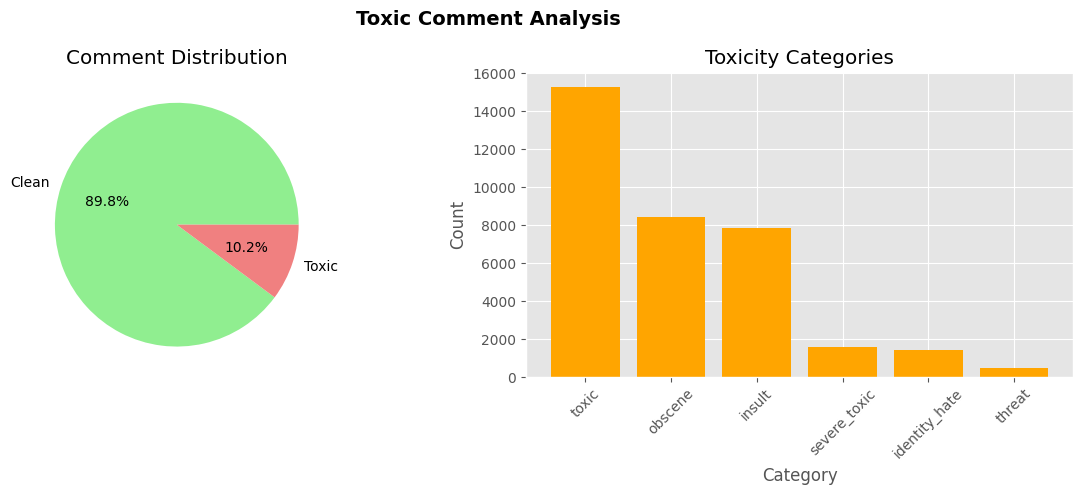

In [ ]:
def create_simple_charts(df, toxicity_columns):
    """Create basic visualizations"""

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Toxic Comment Analysis', fontsize=14, fontweight='bold')

    # 1. Overall distribution
    total_toxic = (df[toxicity_columns].sum(axis=1) > 0).sum()
    total_clean = len(df) - total_toxic

    axes[0].pie([total_clean, total_toxic],
                labels=['Clean', 'Toxic'],
                autopct='%1.1f%%',
                colors=['lightgreen', 'lightcoral'])
    axes[0].set_title('Comment Distribution')

    # 2. Category counts
    category_counts = df[toxicity_columns].sum().sort_values(ascending=False)
    axes[1].bar(range(len(category_counts)), category_counts.values, color='orange')
    axes[1].set_title('Toxicity Categories')
    axes[1].set_xlabel('Category')
    axes[1].set_ylabel('Count')
    axes[1].set_xticks(range(len(category_counts)))
    axes[1].set_xticklabels(category_counts.index, rotation=45)

    plt.tight_layout()
    plt.show()

create_simple_charts(df, toxicity_columns)

In [ ]:
# Prepare text and labels
X = df['comment_text'].values
y = df[toxicity_columns].values

# Setup text vectorization
MAX_FEATURES = 20000
vectorizer = TextVectorization(
    max_tokens=MAX_FEATURES,
    output_mode='int',
    output_sequence_length=1800
)

# Fit and transform text
vectorizer.adapt(X)
vectorized_text = vectorizer(X)

print(f"Text samples processed: {len(X):,}")
print(f"Vocabulary size: {MAX_FEATURES:,}")

# Create TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.batch(16).cache().prefetch(tf.data.AUTOTUNE)

# Simple train/test split
train_size = int(len(dataset) * 0.8)
train_ds = dataset.take(train_size)
test_ds = dataset.skip(train_size)

print(f"Training batches: {train_size}")
print(f"Testing batches: {len(dataset) - train_size}")

Text samples processed: 159,571
Vocabulary size: 20,000
Training batches: 7979
Testing batches: 1995


In [ ]:
def build_simple_model():
    """Build simple LSTM model"""

    model = Sequential([
        Embedding(MAX_FEATURES + 1, 32),
        Bidirectional(LSTM(32, activation='tanh')),
        Dense(128, activation='relu'),
        Dense(len(toxicity_columns), activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

model = build_simple_model()
print("\nModel Architecture:")
model.summary()


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=1,
    verbose=1
)

print("Training completed!")

7979/7979 ━━━━━━━━━━━━━━━━━━━━ 790s 98ms/step - accuracy: 0.9610 - loss: 0.0877 - val_accuracy: 0.9941 - val_loss: 0.0507
Training completed!



MODEL PERFORMANCE
--------------------
Test Accuracy: 0.9941 (99.41%)
Test Loss: 0.0507


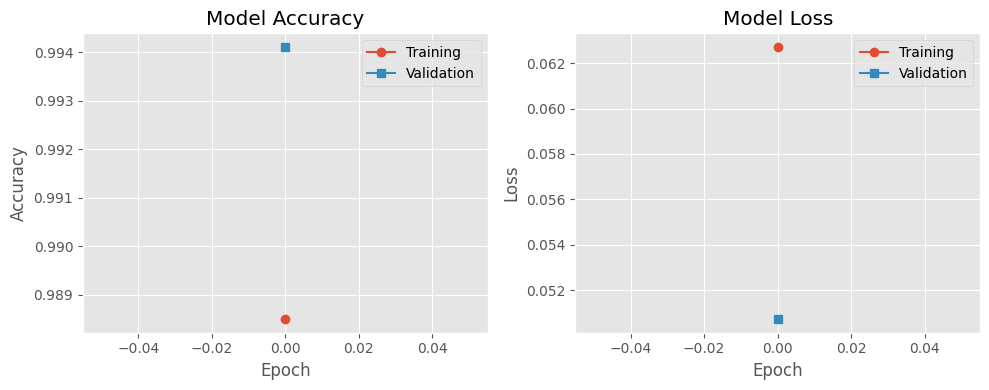

In [ ]:
# Evaluate performance
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"\nMODEL PERFORMANCE")
print("-" * 20)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Plot training history
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training', marker='o')
plt.plot(history.history['val_loss'], label='Validation', marker='s')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def score_comment(comment):
    """Analyze comment for toxicity"""

    # Vectorize comment
    vectorized = vectorizer([comment])

    # Make prediction
    predictions = model.predict(vectorized, verbose=0)[0]

    # Format results
    result_text = "TOXICITY ANALYSIS:\n" + "="*20 + "\n"

    # Overall assessment
    max_score = max(predictions) * 100
    if max_score > 70:
        result_text += "Status: HIGHLY TOXIC\n\n"
    elif max_score > 40:
        result_text += "Status: MODERATELY TOXIC\n\n"
    elif max_score > 20:
        result_text += "Status: POTENTIALLY PROBLEMATIC\n\n"
    else:
        result_text += "Status: CLEAN\n\n"

    # Category scores
    result_text += "Category Scores:\n"
    for i, category in enumerate(toxicity_columns):
        score = predictions[i] * 100
        result_text += f"• {category}: {score:.1f}%\n"

    return result_text

In [ ]:
test_comments = [
    "You are bad",
    "You are completely stupid and worthless!",
    "I disagree but respect your opinion.",
    "I hate this and everyone here!"
]

for i, comment in enumerate(test_comments, 1):
    vectorized = vectorizer([comment])
    prediction = model.predict(vectorized, verbose=0)[0]
    max_toxicity = max(prediction) * 100

    status = "TOXIC" if max_toxicity > 50 else "CLEAN"

    print(f"\n{i}. Comment: \"{comment}\"")
    print(f"   Result: {status} (Score: {max_toxicity:.1f}%)")


1. Comment: "You are bad"
   Result: CLEAN (Score: 26.7%)

2. Comment: "You are completely stupid and worthless!"
   Result: TOXIC (Score: 92.3%)

3. Comment: "I disagree but respect your opinion."
   Result: CLEAN (Score: 0.7%)

4. Comment: "I hate this and everyone here!"
   Result: CLEAN (Score: 26.8%)


In [ ]:
# ============================================================
# GRADIO GUI FOR YOUR TOXICITY MODEL
# Add this cell after your training code
# ============================================================

import gradio as gr
import numpy as np

print("🚀 Building Gradio interface...")

# Capture trained components
_model = model
_vectorizer = vectorizer
_categories = toxicity_columns

print("✅ Model and vectorizer captured!")

def analyze_single(comment):
    """Analyze a single comment for toxicity"""
    if not comment or not comment.strip():
        return "⚠️ Please enter some text to analyze", {}

    try:
        # Vectorize comment
        vectorized = _vectorizer([comment])

        # Make prediction
        predictions = _model.predict(vectorized, verbose=0)[0]

        # Calculate scores
        max_score = float(max(predictions)) * 100
        avg_score = float(np.mean(predictions)) * 100

        # Determine status
        if max_score > 70:
            status = "🚨 HIGHLY TOXIC"
        elif max_score > 40:
            status = "⚠️ MODERATELY TOXIC"
        elif max_score > 20:
            status = "⚡ POTENTIALLY PROBLEMATIC"
        else:
            status = "✅ CLEAN"

        # Build results
        results = {}
        for i, category in enumerate(_categories):
            score = float(predictions[i]) * 100
            results[category] = f"{score:.2f}%"

        results["━━━ SUMMARY ━━━"] = "━━━━━━━━━━"
        results["OVERALL STATUS"] = status
        results["MAX SCORE"] = f"{max_score:.2f}%"
        results["AVG SCORE"] = f"{avg_score:.2f}%"

        return status, results

    except Exception as e:
        import traceback
        return f"❌ Error: {str(e)}", {"error": traceback.format_exc()}

def analyze_batch(text):
    """Analyze multiple comments at once"""
    if not text or not text.strip():
        return "⚠️ Please enter some text to analyze"

    # Split by newlines
    comments = [c.strip() for c in text.split('\n') if c.strip()]

    if not comments:
        return "⚠️ No valid comments found"

    output = [f"📊 Analyzed {len(comments)} comment(s):\n"]
    output.append("=" * 70 + "\n")

    for i, comment in enumerate(comments, 1):
        try:
            # Vectorize and predict
            vectorized = _vectorizer([comment])
            predictions = _model.predict(vectorized, verbose=0)[0]
            max_score = float(max(predictions)) * 100

            # Determine status
            if max_score > 70:
                status = "🚨 HIGHLY TOXIC"
            elif max_score > 40:
                status = "⚠️ MODERATELY TOXIC"
            elif max_score > 20:
                status = "⚡ POTENTIALLY PROBLEMATIC"
            else:
                status = "✅ CLEAN"

            # Truncate long comments
            short_comment = comment[:45] + "..." if len(comment) > 45 else comment

            output.append(f"{i}. {status} ({max_score:.1f}%)")
            output.append(f"   \"{short_comment}\"\n")

        except Exception as e:
            output.append(f"{i}. ❌ ERROR: Could not analyze comment\n")

    return "\n".join(output)

# Create Gradio Interface
with gr.Blocks(title="Toxicity Detection System") as demo:

    gr.Markdown(
        """
        # 🛡️ Toxicity Detection System

        **AI-Powered Comment Moderation** using Bidirectional LSTM

        This model analyzes text across 6 toxicity categories:
        Toxic, Severe Toxic, Obscene, Threat, Insult, Identity Hate
        """
    )

    with gr.Tabs():
        # Tab 1: Single Comment Analysis
        with gr.Tab("📝 Single Comment"):
            gr.Markdown("### Analyze one comment at a time")

            with gr.Row():
                with gr.Column():
                    input_single = gr.Textbox(
                        label="💬 Enter Comment",
                        lines=6,
                        placeholder="Type or paste a comment to analyze...\n\nExample: This is a great discussion!"
                    )

                    with gr.Row():
                        clear_btn = gr.Button("🗑️ Clear", scale=1)
                        analyze_btn = gr.Button("🔍 Analyze", variant="primary", scale=3)

                with gr.Column():
                    status_output = gr.Textbox(label="📊 Status", lines=2)
                    details_output = gr.JSON(label="📋 Detailed Scores")

            gr.Markdown("### 📌 Try These Examples")
            gr.Examples(
                examples=[
                    ["You are an amazing person!"],
                    ["You are fking bad"],
                    ["You are completely stupid and worthless!"],
                    ["I disagree but respect your opinion."],
                    ["I hate this and everyone here!"],
                    ["Great discussion, thank you for sharing!"]
                ],
                inputs=input_single
            )

            # Button actions
            analyze_btn.click(
                fn=analyze_single,
                inputs=input_single,
                outputs=[status_output, details_output]
            )

            input_single.submit(
                fn=analyze_single,
                inputs=input_single,
                outputs=[status_output, details_output]
            )

            clear_btn.click(
                fn=lambda: ("", "", {}),
                outputs=[input_single, status_output, details_output]
            )

        # Tab 2: Batch Analysis
        with gr.Tab("📊 Batch Analysis"):
            gr.Markdown("### Analyze multiple comments at once")
            gr.Markdown("*Enter one comment per line*")

            with gr.Row():
                with gr.Column():
                    input_batch = gr.Textbox(
                        label="💬 Enter Multiple Comments (one per line)",
                        lines=12,
                        placeholder="Comment 1\nComment 2\nComment 3\n...\n\nEach line will be analyzed separately"
                    )

                    with gr.Row():
                        clear_batch_btn = gr.Button("🗑️ Clear", scale=1)
                        batch_btn = gr.Button("🔍 Analyze All", variant="primary", scale=3)

                with gr.Column():
                    output_batch = gr.Textbox(
                        label="📋 Batch Results",
                        lines=20
                    )

            batch_btn.click(
                fn=analyze_batch,
                inputs=input_batch,
                outputs=output_batch
            )

            clear_batch_btn.click(
                fn=lambda: ("", ""),
                outputs=[input_batch, output_batch]
            )

        # Tab 3: Model Information
        with gr.Tab("ℹ️ Model Info"):
            gr.Markdown(
                f"""
                ## 📖 Model Information

                ### Architecture
                - **Type:** Bidirectional LSTM Neural Network
                - **Embedding Dimension:** 32
                - **LSTM Units:** 32 (bidirectional)
                - **Dense Layer:** 128 units with ReLU
                - **Output Layer:** {len(_categories)} units with sigmoid

                ### Training Configuration
                - **Vocabulary Size:** {MAX_FEATURES:,} tokens
                - **Max Sequence Length:** 1,800 tokens
                - **Optimizer:** Adam
                - **Loss Function:** Binary Crossentropy
                - **Test Accuracy:** {test_accuracy:.2%}

                ### Toxicity Categories ({len(_categories)} types)

                1. **Toxic** - General toxicity or rudeness
                2. **Severe Toxic** - Extremely toxic or hateful content
                3. **Obscene** - Profanity or vulgar language
                4. **Threat** - Threatening or intimidating language
                5. **Insult** - Insulting or degrading language
                6. **Identity Hate** - Hate speech targeting identity groups

                ### Score Interpretation

                | Score Range | Status | Description |
                |-------------|--------|-------------|
                | 0-20% | ✅ Clean | Content is appropriate and non-toxic |
                | 20-40% | ⚡ Potentially Problematic | May contain borderline content |
                | 40-70% | ⚠️ Moderately Toxic | Contains toxic elements |
                | 70-100% | 🚨 Highly Toxic | Severely toxic or harmful content |

                ### Usage Notes

                💡 **Best Practices:**
                - Enter complete sentences for best results
                - The model works best with social media style text
                - Multiple categories can be detected in one comment
                - Use batch analysis for efficiency with many comments

                ⚠️ **Important:**
                - This tool assists human moderation, not replaces it
                - Always review flagged content with human judgment
                - Context matters in moderation decisions

                ---

                **Dataset:** Jigsaw Toxic Comment Classification
                **Framework:** TensorFlow/Keras
                **Interface:** Gradio
                """
            )

    gr.Markdown(
        """
        ---

        ### 🔒 Privacy Notice
        All processing happens in this Colab session. No data is stored or transmitted externally.

        ---

        **Built with TensorFlow and Gradio** | Run in Google Colab
        """
    )

# Close any existing instances
try:
    demo.close()
except:
    pass

# Launch the interface
print("\n" + "=" * 60)
print("🚀 LAUNCHING GRADIO INTERFACE")
print("=" * 60)
print("\n✅ Interface will open automatically!")
print("📍 Local URL: http://127.0.0.1:7860")
print("\n💡 Tip: You can re-run just this cell anytime to restart the GUI")
print("=" * 60 + "\n")

demo.launch(share=False, debug=False, quiet=True)

print("✅ Gradio interface is now LIVE!")
print("🎯 Test it with different comments to see the toxicity detection in action!")

🚀 Building Gradio interface...
✅ Model and vectorizer captured!

🚀 LAUNCHING GRADIO INTERFACE

✅ Interface will open automatically!
📍 Local URL: http://127.0.0.1:7860

💡 Tip: You can re-run just this cell anytime to restart the GUI



<IPython.core.display.Javascript object>

✅ Gradio interface is now LIVE!
🎯 Test it with different comments to see the toxicity detection in action!
